
### Enhancing the Model Performance with Advanced Techniques:

- Using RobustScaler for numerical features
- Using Ordinal Encoding for categorical features
- Domain-specific Feature Engineering - adding 3 features: byte_ratio, pkt_ratio, byte_rate

#### 1. Import Data and Required Packages

In [1]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns

# Preprocessing
from sklearn.preprocessing import OrdinalEncoder, RobustScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Model building and evaluation
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.base import BaseEstimator, OutlierMixin
from sklearn.ensemble import IsolationForest
from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
    precision_recall_curve,
    f1_score
)

import warnings
warnings.filterwarnings('ignore')

Importing the training Dataset

In [2]:
df = pd.read_csv("../data/UNSW_NB15_training-set.csv")

In [3]:
df.shape

(175341, 45)

### 2. Data Preprocessing

In [4]:
# making a clean copy
df_prep = df.copy()

# dropping target leakage column, and unnecessary column
df_prep = df_prep.drop(columns=['attack_cat','id'], errors='ignore')

#fixing categorical column
df_prep['service'] = df_prep['service'].replace('-', 'unknown', regex=True)

# Log transformation for skewed features
log_features = ['dur', 'sbytes', 'dbytes', 'spkts', 'dpkts']

for col in log_features:
    df_prep[col + '_log'] = np.log1p(df_prep[col])


# Add engineered cybersecurity features
df_prep['byte_ratio'] = df_prep['sbytes'] / (df_prep['dbytes'] + 1)
df_prep['pkt_ratio']  = df_prep['spkts'] / (df_prep['dpkts'] + 1)
df_prep['byte_rate']  = df_prep['sbytes'] / (df_prep['dur'] + 1)
#df_prep['burst_rate'] = (df_prep['spkts'] + df_prep['dpkts']) / (df_prep['dur'] + 1)

#df_prep['burst_rate_log'] = np.log1p(df_prep['burst_rate'])

In [5]:
#seperate target
y = df_prep['label']

#Auto-detect categorical + numeric columns
df_features = df_prep.drop(columns=['label'])
categorical_cols = df_features.select_dtypes(include=['object']).columns.tolist()
numeric_cols = df_features.select_dtypes(exclude=['object']).columns.tolist()

print("Categorical:", categorical_cols)
print("Numeric:", len(numeric_cols), "features")

Categorical: ['proto', 'service', 'state']
Numeric: 47 features


In [6]:
# preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', RobustScaler(), numeric_cols),
        ('cat', OrdinalEncoder(handle_unknown='use_encoded_value', unknown_value=-1), categorical_cols)
    ],
    remainder='drop'
)


### 3. Train-Test-Split

In [7]:
train_df, test_df = train_test_split(
    df_prep,
    test_size=0.2,
    stratify=df_prep['label'],
    random_state=42
)

#Train only on NORMAL data (for anomaly detection)
train_normal_df = train_df[train_df['label'] == 0]

### 4. Tranform Train and Test data

In [8]:
X_train = preprocessor.fit_transform(train_normal_df)
X_test  = preprocessor.transform(test_df)

y_test = test_df['label'].values

### 4. Core Model: Isolation Forest
Train Isolation Forest

In [9]:
iso = IsolationForest(
    n_estimators=300,
    max_samples=1.0,
    contamination=0.3,
    random_state=42,
    n_jobs=-1
)

iso.fit(X_train)

,n_estimators,300
,max_samples,1.0
,contamination,0.3
,max_features,1.0
,bootstrap,False
,n_jobs,-1
,random_state,42
,verbose,0
,warm_start,False


Predict Anamoly Score

In [ ]:
#predictions with final model
scores = iso.decision_function(X_test)                # higher = normal
preds = iso.predict(X_test)                           # 1 = normal, -1 = anomaly
preds_binary = [1 if p == -1 else 0 for p in preds]   # convert to 1 = anomaly

Evaluation - confusion matrix

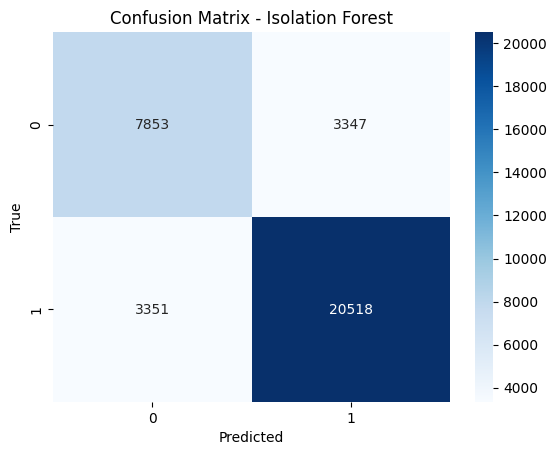

In [11]:
cm = confusion_matrix(y_test, preds_binary)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted"); plt.ylabel("True")
plt.title("Confusion Matrix - Isolation Forest")
plt.show()

Classification Report

In [13]:
print(classification_report(y_test, preds_binary))

              precision    recall  f1-score   support

           0       0.70      0.70      0.70     11200
           1       0.86      0.86      0.86     23869

    accuracy                           0.81     35069
   macro avg       0.78      0.78      0.78     35069
weighted avg       0.81      0.81      0.81     35069



ROC-AUC

In [14]:
auc = roc_auc_score(y_test, -scores)  # invert score: higher = anomaly
print("ROC-AUC:", round(auc, 4))

ROC-AUC: 0.8659


ROC curve

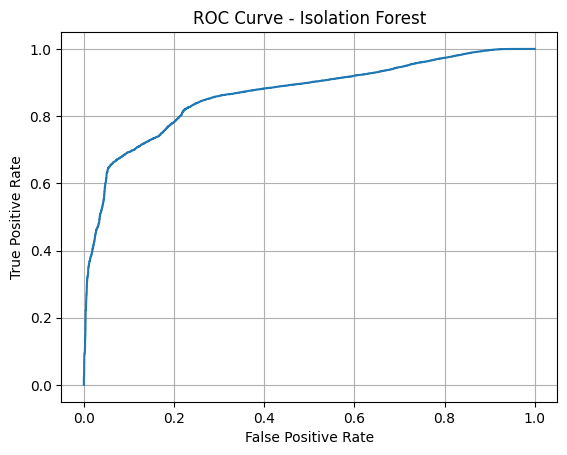

In [15]:
fpr, tpr, _ = roc_curve(y_test, -scores)

plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Isolation Forest")
plt.grid(True)
plt.show()

In [16]:
#saving
import joblib

joblib.dump(iso, "model.pkl")

['model.pkl']